<a href="https://colab.research.google.com/github/simmibaghel/Hospital_Readmission_Risk_Analysis/blob/main/Hospital_Resubmissin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
# (Make sure the file name matches exactly what you downloaded)
df = pd.read_csv('/content/diabetic_data.csv')

print("Original Data Size:", df.shape)

# 2. Fix the missing values
# The hospital system recorded missing data as '?', let's turn that into standard NaN (Not a Number)
df.replace('?', np.nan, inplace=True)

# 3. Drop useless columns
# 'weight', 'payer_code', and 'medical_specialty' are missing 40% to 90% of their data, so they are useless for our model.
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])

# 4. Create our "Target" Variable
# We want to predict if someone is readmitted in UNDER 30 days.
# We will make a new column: 1 means Yes (<30 days), 0 means No (or >30 days)
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 5. Clean up the remaining missing rows
df = df.dropna(subset=['race', 'gender'])

print("Cleaned Data Size:", df.shape)
print("\nTotal High-Risk (<30 days) vs Low-Risk Patients:")
print(df['readmitted_binary'].value_counts())

Original Data Size: (101766, 50)
Cleaned Data Size: (99493, 48)

Total High-Risk (<30 days) vs Low-Risk Patients:
readmitted_binary
0    88324
1    11169
Name: count, dtype: int64


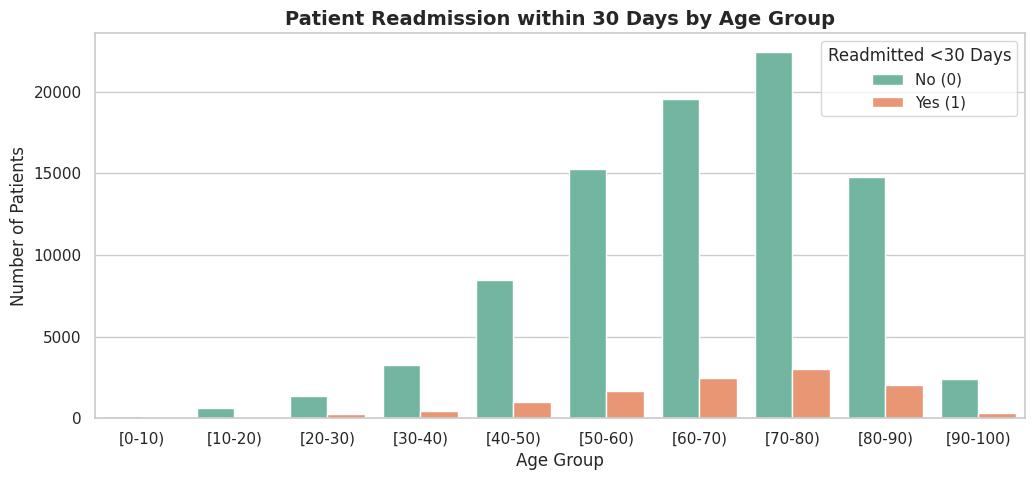

/tmp/ipython-input-2556139729.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='readmitted_binary', y='number_inpatient', palette='coolwarm')


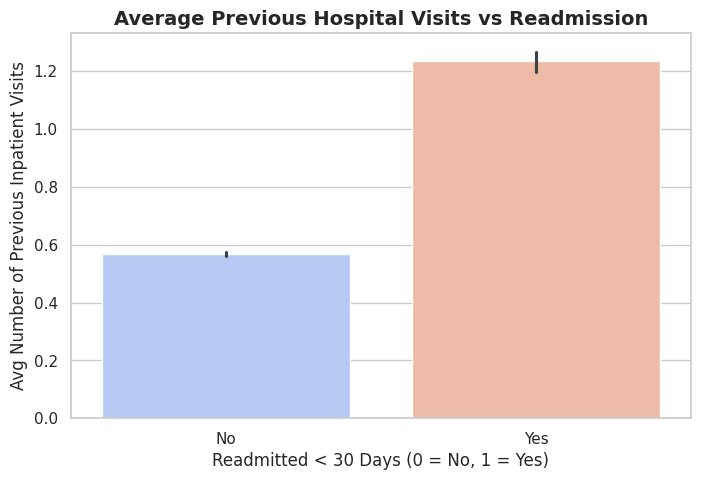

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style to look professional
sns.set_theme(style="whitegrid")

# Chart 1: How does Age affect Readmission?
plt.figure(figsize=(12, 5))
# The dataset has age in brackets like [70-80). Let's plot it!
sns.countplot(data=df, x='age', hue='readmitted_binary', palette='Set2',
              order=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])
plt.title('Patient Readmission within 30 Days by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted <30 Days', labels=['No (0)', 'Yes (1)'])
plt.show()

# Chart 2: Do "Frequent Flyers" (people who visit the hospital often) get readmitted more?
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='readmitted_binary', y='number_inpatient', palette='coolwarm')
plt.title('Average Previous Hospital Visits vs Readmission', fontsize=14, fontweight='bold')
plt.xlabel('Readmitted < 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Avg Number of Previous Inpatient Visits')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Pick our Clues (Features) and our Target
# We are selecting the columns that make the most logical sense for readmission
features = ['age', 'time_in_hospital', 'num_lab_procedures',
            'num_medications', 'number_inpatient', 'number_emergency', 'diabetesMed']

X = df[features]
y = df['readmitted_binary'] # This is the 1 or 0 we created earlier

# 2. Translate Text to Numbers (Machine Learning only understands math!)
# This turns categories like 'age' into binary columns (0 or 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split the Data (80% for Training, 20% for Testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Training the AI model... (This might take 10-20 seconds!)")

# 4. Build and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Give the AI a Test!
predictions = rf_model.predict(X_test)

# 6. Check the Score
accuracy = accuracy_score(y_test, predictions)
print("\n--- MODEL RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

Training the AI model... (This might take 10-20 seconds!)

--- MODEL RESULTS ---
Overall Accuracy: 85.75%


In [ ]:
# 1. Feature Engineering (Creating Smarter Clues)
# Combine all past visits into a single "Frequent Flyer" score
df['total_hospital_activity'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']

# Let's add 'number_diagnoses' to see if sicker patients return more
new_features = ['age', 'time_in_hospital', 'num_lab_procedures',
                'num_medications', 'total_hospital_activity', 'diabetesMed', 'number_diagnoses']

X_new = df[new_features]
y_new = df['readmitted_binary']

# 2. Translate Text to Numbers
X_encoded_new = pd.get_dummies(X_new, drop_first=True)

# 3. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X_encoded_new, y_new, test_size=0.2, random_state=42)

print("Training the upgraded model... (Adding more trees!)")

# 4. Build a Tuned Random Forest
# We doubled the estimators (trees) and restricted the depth so it doesn't overthink
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
rf_model_tuned.fit(X_train, y_train)

# 5. Score it
predictions_tuned = rf_model_tuned.predict(X_test)

# Let's look at the actual breakdown
from sklearn.metrics import classification_report
print("\n--- UPGRADED MODEL RESULTS ---")
print(f"New Overall Accuracy: {accuracy_score(y_test, predictions_tuned) * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(y_test, predictions_tuned))

Training the upgraded model... (Adding more trees!)

--- UPGRADED MODEL RESULTS ---
New Overall Accuracy: 68.31%

Detailed Breakdown:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80     17724
           1       0.16      0.45      0.24      2175

    accuracy                           0.68     19899
   macro avg       0.54      0.58      0.52     19899
weighted avg       0.83      0.68      0.74     19899



In [ ]:
# Add the AI's predictions back into our clean dataset
df_results = df.copy()

# We need to run the whole dataset through our translation pipeline first
X_all = pd.get_dummies(df[new_features], drop_first=True)

# Add the predictions
df_results['Risk_Prediction'] = rf_model_tuned.predict(X_all)

# Save it to a new CSV file for Power BI
df_results.to_csv('Hospital_Readmission_Predictions.csv', index=False)
print("Data successfully exported! Check your folder for 'Hospital_Readmission_Predictions.csv'")

Data successfully exported! Check your folder for 'Hospital_Readmission_Predictions.csv'
